<a href="https://colab.research.google.com/github/euleralencar/projeto_ciencia_dados_ibmec/blob/main/03_02_categorical_pipeline_column_transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Usando variáveis numéricas e categóricas juntas

Nos notebooks anteriores, mostramos o pré-processamento necessário para lidar
com variáveis numéricas e categóricas. No entanto, desacoplamos o processo para
tratar cada tipo individualmente. Neste notebook, mostramos como combinar essas
etapas de pré-processamento.

Primeiro, carregamos o conjunto de dados completo do censo norte-americano.

In [1]:
import pandas as pd

adult_census = pd.read_csv(
    "https://raw.githubusercontent.com/INRIA/scikit-learn-mooc/main/datasets/adult-census.csv"
)

In [2]:
# remove a coluna duplicada `"education-num"` conforme indicado no primeiro notebook
adult_census = adult_census.drop(columns="education-num")

target_name = "class"
target = adult_census[target_name]

data = adult_census.drop(columns=[target_name])

## Seleção com base no tipo de dado

Separamos as variáveis categóricas e numéricas usando seus tipos de dado para
identificá-las, já que vimos anteriormente que `object` corresponde a colunas
categóricas (strings). Usamos o utilitário `make_column_selector` para
selecionar as colunas correspondentes.

In [3]:
from sklearn.compose import make_column_selector as selector

numerical_columns_selector = selector(dtype_exclude=object)
categorical_columns_selector = selector(dtype_include=object)

numerical_columns = numerical_columns_selector(data)
categorical_columns = categorical_columns_selector(data)

<div class="admonition caution alert alert-warning">
<p class="first admonition-title" style="font-weight: bold;">Cuidado!</p>
<p>Aqui, sabemos que o tipo de dado <tt class="docutils literal">object</tt> é
usado para representar strings e, portanto, features categóricas. Saiba que
isso nem sempre é o caso. Às vezes, o tipo de dado
<tt class="docutils literal">object</tt> pode conter outros tipos de
informação, como datas que não foram formatadas corretamente (strings) e que,
ainda assim, se referem a uma quantidade de tempo decorrido.</p>
<p class="last">Em um cenário mais geral, você deve inspecionar manualmente o
conteúdo do seu dataframe para não usar incorretamente o
<tt class="docutils literal">make_column_selector</tt>.</p>
</div>

## Direcionar colunas para um processador específico

Nas seções anteriores, vimos que precisamos tratar os dados de forma diferente
dependendo da sua natureza (ou seja, numérica ou categórica).

O scikit-learn fornece uma classe `ColumnTransformer` que envia colunas
específicas para um transformador específico, facilitando o ajuste de um único
modelo preditivo em um conjunto de dados que combina os dois tipos de variáveis
(dados tabulares heterogeneamente tipados).

Primeiro, definimos as colunas de acordo com seu tipo de dado:

* **codificação one-hot** é aplicada às colunas categóricas. Além disso, usamos
  `handle_unknown="ignore"` para resolver possíveis problemas causados por
  categorias raras.
* **escalonamento numérico** para as features numéricas, que serão
  padronizadas.

Agora, criamos nosso `ColumnTransfomer` usando a função utilitária
`make_column_transformer`. Especificamos dois valores: o transformador e as
colunas. Primeiro, vamos criar os pré-processadores para as partes numérica e
categórica.

In [4]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_preprocessor = OneHotEncoder(handle_unknown="ignore")
numerical_preprocessor = StandardScaler()

Agora, criamos o transformador e associamos cada um desses pré-processadores às
suas respectivas colunas.

In [5]:
from sklearn.compose import make_column_transformer

preprocessor = make_column_transformer(
    (categorical_preprocessor, categorical_columns),
    (numerical_preprocessor, numerical_columns),
)

Podemos parar um momento para representar graficamente a estrutura de um
`ColumnTransformer`:


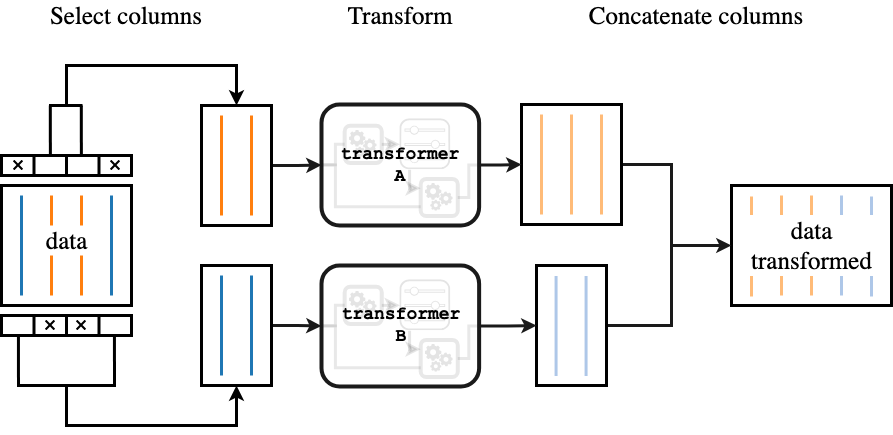


Um `ColumnTransformer` faz o seguinte:

* Ele **divide as colunas** do conjunto de dados original com base nos nomes ou
  índices de coluna fornecidos. Obtemos tantos subconjuntos quanto o número de
  transformadores passados ao `ColumnTransformer`.
* Ele **transforma cada subconjunto**. Um transformador específico é aplicado a
  cada subconjunto: ele chama internamente `fit_transform` ou `transform`. A
  saída dessa etapa é um conjunto de dados transformados.
* Em seguida, ele **concatena os conjuntos de dados transformados** em um único
  conjunto de dados.

O importante é que o `ColumnTransformer` é como qualquer outro transformador do
scikit-learn. Em particular, ele pode ser combinado com um classificador em um
`Pipeline`:

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

model = make_pipeline(preprocessor, LogisticRegression(max_iter=500))
model

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['workclass', 'education',
                                                   'marital-status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native-country']),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  ['age', 'capital-gain',
                                                   'capital-loss',
                                                   'hours-per-week'])])),
                ('logisticregression', LogisticRegression(max_iter=500))])

O modelo final é mais complexo do que os modelos anteriores, mas ainda segue a
mesma API (o mesmo conjunto de métodos que podem ser chamados pelo usuário):

- o método `fit` é chamado para pré-processar os dados e depois treinar o
  classificador com os dados pré-processados;
- o método `predict` faz previsões em novos dados;
- o método `score` é usado para prever nos dados de teste e comparar as
  previsões com os rótulos de teste esperados para calcular a acurácia.

Vamos começar dividindo nossos dados em conjuntos de treino e teste.

In [7]:
from sklearn.model_selection import train_test_split

data_train, data_test, target_train, target_test = train_test_split(
    data, target, random_state=42
)


<div class="admonition caution alert alert-warning">
<p class="first admonition-title" style="font-weight: bold;">Cuidado!</p>
<p class="last">Saiba que usamos <tt class="docutils literal">train_test_split</tt>
aqui por motivos didáticos, para mostrar a API do scikit-learn. Em um cenário
real, pode ser preferível usar validação cruzada para também conseguir avaliar
a incerteza da nossa estimativa do desempenho de generalização de um modelo,
como demonstrado anteriormente.</p>
</div>

Agora, podemos treinar o modelo no conjunto de treino.

In [8]:
_ = model.fit(data_train, target_train)

Em seguida, podemos enviar o conjunto de dados bruto diretamente para o
pipeline. De fato, não precisamos fazer nenhum pré-processamento manual
(chamando os métodos `transform` ou `fit_transform`), pois isso já é tratado ao
chamar o método `predict`. Como exemplo, fazemos previsões nas cinco primeiras
amostras do conjunto de teste.

In [9]:
data_test

,age,workclass,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
7762,56,Private,HS-grad,Divorced,Other-service,Unmarried,White,Female,0,0,40,United-States
23881,25,Private,HS-grad,Married-civ-spouse,Transport-moving,Own-child,Other,Male,0,0,40,United-States
30507,43,Private,Bachelors,Divorced,Prof-specialty,Not-in-family,White,Female,14344,0,40,United-States
28911,32,Private,HS-grad,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,40,United-States
19484,39,Private,Bachelors,Married-civ-spouse,Sales,Wife,White,Female,0,0,30,United-States
...,...,...,...,...,...,...,...,...,...,...,...,...
30726,34,Private,Bachelors,Married-civ-spouse,Tech-support,Husband,White,Male,0,0,40,England
7744,29,Private,5th-6th,Married-civ-spouse,Handlers-cleaners,Not-in-family,White,Male,0,0,40,Mexico
19832,24,Private,Some-college,Never-married,Sales,Not-in-family,Black,Male,0,0,40,Jamaica
42129,42,Self-emp-not-inc,7th-8th,Married-civ-spouse,Other-service,Wife,Black,Female,0,0,50,United-States


In [10]:
model.predict(data_test)[:5]

array([' <=50K', ' <=50K', ' >50K', ' <=50K', ' >50K'], dtype=object)

In [11]:
target_test[:5]

,class
7762,<=50K
23881,<=50K
30507,>50K
28911,<=50K
19484,<=50K


Para obter diretamente o score de acurácia, precisamos chamar o método `score`.
Vamos calcular o score de acurácia em todo o conjunto de teste.

In [12]:
model.score(data_test, target_test)

0.8575055278028008

## Avaliação do modelo com validação cruzada

Como afirmado anteriormente, um modelo preditivo deve ser avaliado por
validação cruzada. Nosso modelo pode ser usado com as ferramentas de validação
cruzada do scikit-learn como qualquer outro preditor:

In [13]:
from sklearn.model_selection import cross_validate

cv_results = cross_validate(model, data, target, cv=5)
cv_results

{'fit_time': array([1.32305956, 1.3077364 , 0.8114152 , 1.28346491, 1.64836144]),
 'score_time': array([0.13606596, 0.14073586, 0.10180259, 0.13842893, 0.1603024 ]),
 'test_score': array([0.85116184, 0.84993346, 0.8482801 , 0.85257985, 0.85544636])}

In [14]:
scores = cv_results["test_score"]
print(
    "A acurácia média da validação cruzada é: "
    f"{scores.mean():.3f} ± {scores.std():.3f}"
)

A acurácia média da validação cruzada é: 0.851 ± 0.002


O modelo composto tem uma acurácia preditiva maior do que os dois modelos que
usaram variáveis numéricas e categóricas isoladamente.

## Ajustando um modelo mais poderoso

**Modelos lineares** são interessantes porque geralmente são baratos de
treinar, **pequenos** para implantar, **rápidos** para prever e oferecem uma
**boa referência (baseline)**.

No entanto, muitas vezes é útil verificar se modelos mais complexos, como um
ensemble de árvores de decisão, podem levar a um desempenho preditivo maior.
Nesta seção, usamos um modelo desse tipo, chamado **árvores de gradient
boosting**, e avaliamos seu desempenho de generalização. Mais precisamente, o
modelo do scikit-learn que usamos é chamado `HistGradientBoostingClassifier`.
Note que modelos de boosting serão abordados em mais detalhes em um módulo
futuro.

Para modelos baseados em árvores, o tratamento de variáveis numéricas e
categóricas é mais simples do que para modelos lineares:

* **não precisamos escalonar as features numéricas**
* usar uma **codificação ordinal para as variáveis categóricas** é adequado,
  mesmo que a codificação resulte em uma ordenação arbitrária

Portanto, para o `HistGradientBoostingClassifier`, o pipeline de
pré-processamento é um pouco mais simples do que aquele que vimos anteriormente
para a `LogisticRegression`:

In [15]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import OrdinalEncoder

categorical_preprocessor = OrdinalEncoder(
    handle_unknown="use_encoded_value", unknown_value=-1
)

preprocessor = make_column_transformer(
    (categorical_preprocessor, categorical_columns),
    remainder="passthrough",
)

model = make_pipeline(preprocessor, HistGradientBoostingClassifier())

Agora que criamos nosso modelo, podemos verificar seu desempenho de
generalização.

In [16]:
%%time
_ = model.fit(data_train, target_train)

CPU times: user 1.52 s, sys: 17.2 ms, total: 1.54 s
Wall time: 3.08 s


In [17]:
model.score(data_test, target_test)

0.8801899926295963

Podemos observar que obtemos acurácias significativamente maiores com o modelo
de Gradient Boosting. Isso é frequentemente o que observamos sempre que o
conjunto de dados tem um grande número de amostras e um número limitado de
features informativas (por exemplo, menos de 1000), com uma mistura de
variáveis numéricas e categóricas.

Isso explica por que as Gradient Boosted Machines são muito populares entre
profissionais de ciência de dados que trabalham com dados tabulares.

Neste notebook, nós:

* usamos um `ColumnTransformer` para aplicar pré-processamentos diferentes para
  variáveis categóricas e numéricas;
* usamos um pipeline para encadear o pré-processamento do `ColumnTransformer` e
  o ajuste da regressão logística;
* vimos que **métodos de gradient boosting** podem superar **modelos
  lineares**.